PHASE ONE

In [1]:
import os
import torch
import random
import numpy as np
import pandas as pd

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.utils.class_weight import compute_class_weight

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
DATASET_PATH = "/kaggle/input/datasets/menaka4/x-ray-4class"

train_dir = os.path.join(DATASET_PATH, "train")
test_dir  = os.path.join(DATASET_PATH, "test")

print("Train path:", train_dir)
print("Test path :", test_dir)

Train path: /kaggle/input/datasets/menaka4/x-ray-4class/train
Test path : /kaggle/input/datasets/menaka4/x-ray-4class/test


In [4]:
train_transforms = transforms.Compose([

    transforms.Resize((256,256)),

    transforms.RandomResizedCrop(224),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_test_transforms = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


In [5]:
full_train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transforms
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=val_test_transforms
)



In [6]:
train_size = int(0.8 * len(full_train_dataset))
val_size   = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

val_dataset.dataset.transform = val_test_transforms


In [7]:
dataset_summary = pd.DataFrame({

    "Split": ["Train", "Validation", "Test"],

    "Images": [
        len(train_dataset),
        len(val_dataset),
        len(test_dataset)
    ]
})   

print("\nDataset Summary:\n")

print(dataset_summary)

print("\nTotal Images:",
      len(train_dataset) +
      len(val_dataset) +
      len(test_dataset))


Dataset Summary:

        Split  Images
0       Train    5060
1  Validation    1266
2        Test     771

Total Images: 7097


In [8]:
class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
Number of classes: 4


In [9]:
targets = [label for _, label in full_train_dataset.samples]

class_counts = pd.Series(targets).value_counts().sort_index()

distribution = pd.DataFrame({
    "Class": class_names,
    "Images": class_counts.values
})

print("\nClass Distribution:")
print(distribution)


Class Distribution:
           Class  Images
0        COVID19     460
1         NORMAL    1341
2      PNEUMONIA    3875
3  TURBERCULOSIS     650


In [10]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(targets),
    y=targets
)

class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print("\nClass weights:", class_weights)


Class weights: tensor([3.4380, 1.1793, 0.4081, 2.4331], device='cuda:0')


In [11]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("\nDataLoaders ready")


DataLoaders ready


In [12]:
metadata = {

    "classes": class_names,
    "num_classes": num_classes,
    "train_size": len(train_dataset),
    "val_size": len(val_dataset),
    "test_size": len(test_dataset)

}

torch.save(metadata, "/kaggle/working/dataset_metadata.pth")
torch.save(class_weights, "/kaggle/working/class_weights.pth")

print("\nMetadata saved")


Metadata saved


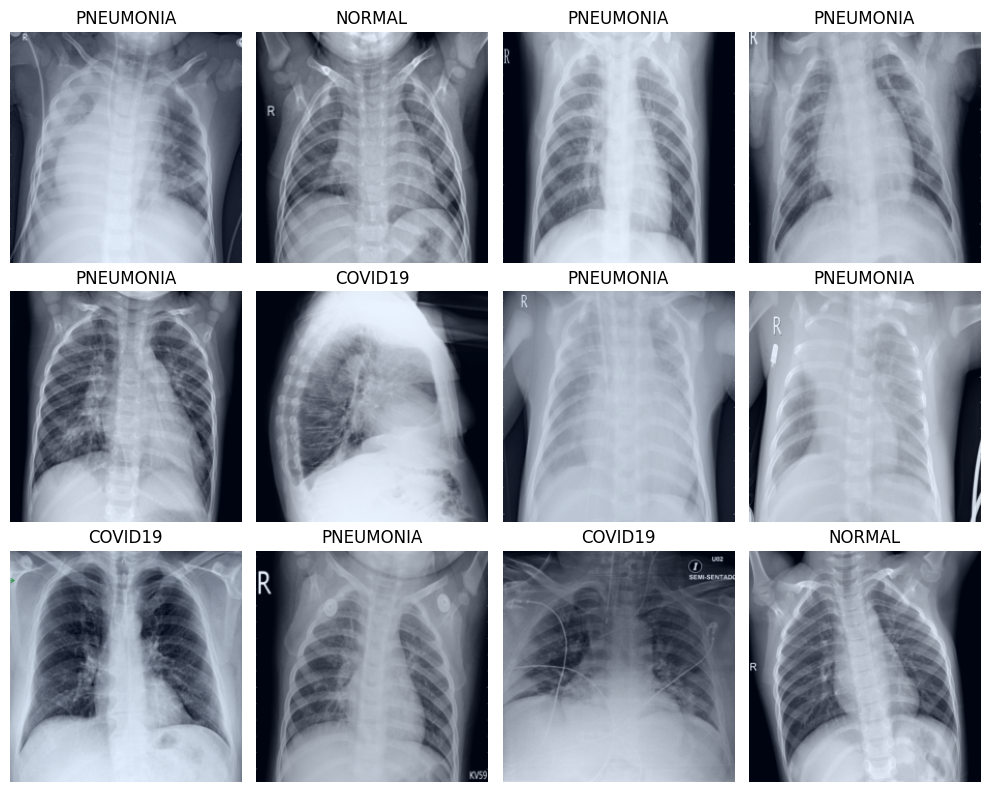

In [57]:
import matplotlib.pyplot as plt 

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(3,4, figsize=(10,8))

axes = axes.flatten()

for i in range(12):
    
    img = images[i].permute(1,2,0).cpu().numpy()
    
    img = (img - img.min())/(img.max()-img.min())
    
    axes[i].imshow(img)
    
    axes[i].set_title(class_names[labels[i]])
    
    axes[i].axis("off")

plt.tight_layout()
plt.show()

VIT

In [58]:
!pip install timm

In [14]:
import timm
import torch.nn as nn
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [15]:
metadata = torch.load("/kaggle/working/dataset_metadata.pth")
class_weights = torch.load("/kaggle/working/class_weights.pth")

num_classes = metadata["num_classes"]

print("Classes:", num_classes)

Classes: 4


In [16]:
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=num_classes
)

model = model.to(device)

print(" ViT loaded")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

 ViT loaded


In [17]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [18]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

In [19]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

In [ ]:
def train_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() #clear previous gradient

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()  #weight updater

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    acc = 100 * correct / total

    return running_loss/len(loader), acc

In [21]:
def validate_epoch(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    acc = 100 * correct / total

    return running_loss/len(loader), acc

In [22]:
epochs = 20

best_val_acc = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_epoch(model, train_loader)

    val_loss, val_acc = validate_epoch(model, val_loader)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # print("Train Acc:", train_acc)
    print("Val Acc:", val_acc)
    print("Val loss:", val_loss)

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "/kaggle/working/plain_vit_best.pth"
        )

        print("Best model saved")


Epoch 1/20


100%|██████████| 159/159 [01:35<00:00,  1.66it/s]


Val Acc: 95.65560821484992
Val loss: 0.07109578992240131
Best model saved

Epoch 2/20


100%|██████████| 159/159 [01:35<00:00,  1.67it/s]


Val Acc: 83.72827804107425
Val loss: 0.24885965827852488

Epoch 3/20


...

Val Acc: 98.65718799368088
Val loss: 0.043557076385570784

Epoch 19/20


100%|██████████| 159/159 [01:35<00:00,  1.67it/s]


Val Acc: 98.5781990521327
Val loss: 0.04410104275232243

Epoch 20/20


100%|██████████| 159/159 [01:35<00:00,  1.67it/s]


Val Acc: 98.5781990521327
Val loss: 0.0443973942537184


In [23]:
model.load_state_dict(
    torch.load("/kaggle/working/plain_vit_best.pth")
)   
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [24]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [25]:
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(all_labels, all_preds, average="weighted")

recall = recall_score(all_labels, all_preds, average="weighted")

f1 = f1_score(all_labels, all_preds, average="weighted")

macro_f1 = f1_score(all_labels, all_preds, average="macro")

weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print("\n Vision Transformer Performance:")
print("---------------------")

print("F1 Score for VIT:", f1)
print('\n')
print("Accuracy:", accuracy)
print('\n')
print("Precision:", precision)
print("Recall:", recall)



 Vision Transformer Performance:
---------------------
F1 Score for VIT: 0.8142509724055119


Accuracy: 0.833981841763943


Precision: 0.8725220040382696
Recall: 0.833981841763943


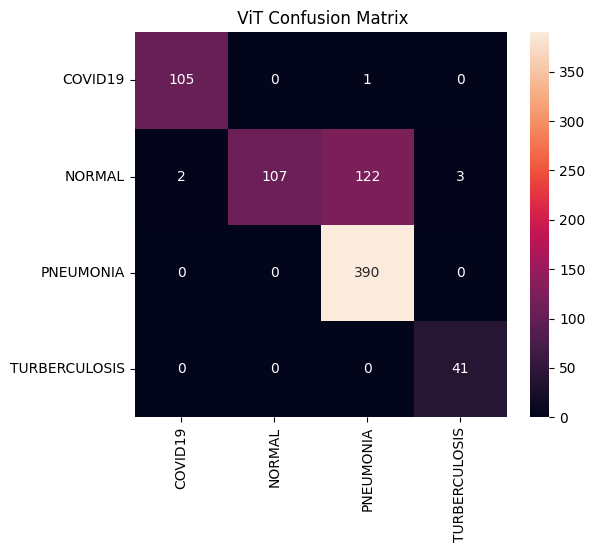

In [26]:
import seaborn as sns 
import matplotlib.pyplot as plt 

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(" ViT Confusion Matrix")

plt.show()

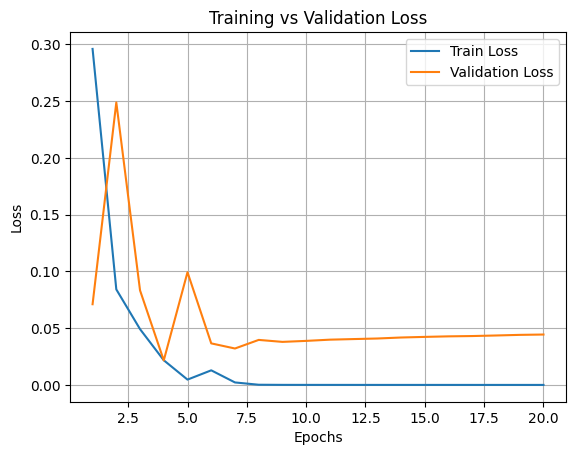

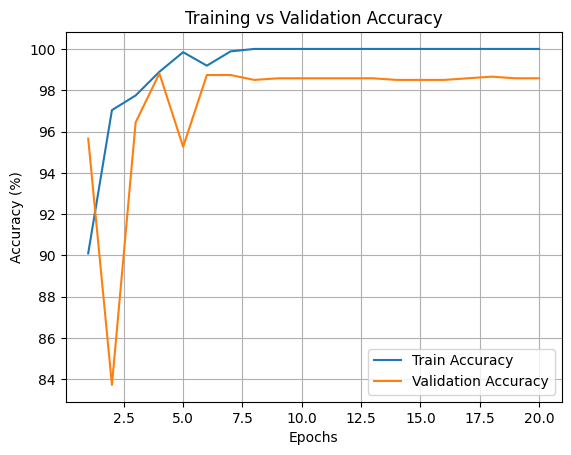

In [27]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()


plt.figure()
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

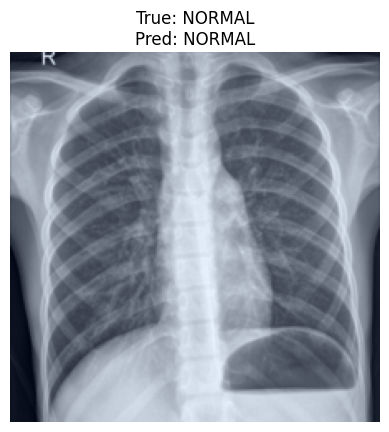

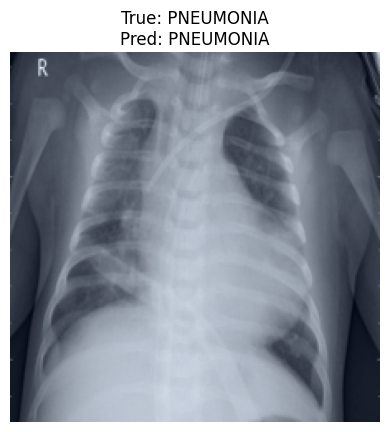

In [75]:
import matplotlib.pyplot as plt
import random

chosen_dataset = test_dataset   

indices = random.sample(range(len(chosen_dataset)), 2)

for idx in indices:
    img, label = chosen_dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)

    img_np = img.permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    plt.imshow(img_np)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred.item()]}")
    plt.axis("off")
    plt.show()


PROPOSED VIT

In [28]:
import torch
import torch.nn as nn
import timm
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [29]:
metadata = torch.load("/kaggle/working/dataset_metadata.pth")
class_weights = torch.load("/kaggle/working/class_weights.pth")

num_classes = metadata["num_classes"]

print("Classes:", num_classes)

Classes: 4


In [30]:
class SPT(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, x):

        shifts = [
            (0,0),
            (1,0),
            (-1,0),
            (0,1),
            (0,-1)
        ]

        xs = []

        for dy,dx in shifts:
            xs.append(torch.roll(x, shifts=(dy,dx), dims=(2,3)))

        x = torch.stack(xs).mean(0)

        return x

In [31]:
class TokenLearner(nn.Module):

    def __init__(self, dim, num_tokens=8):

        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, num_tokens)
        )

    def forward(self, x):

        attn = self.attention(x)

        attn = attn.softmax(dim=1)

        tokens = torch.einsum("bnd,bnk->bkd", x, attn)

        return tokens

In [32]:
class ProposedViT(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.spt = SPT()

        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0
        )

        dim = self.backbone.num_features

        self.token_learner = TokenLearner(dim)

        self.norm = nn.LayerNorm(dim)

        self.drop = nn.Dropout(0.3)

        self.fc = nn.Linear(dim, num_classes)

    def forward(self, x):

        x = self.spt(x)

        x = self.backbone.forward_features(x)

        x = x[:,1:,:]

        tokens = self.token_learner(x)

        x = tokens.mean(dim=1)

        x = self.norm(x)

        x = self.drop(x)

        x = self.fc(x)

        return x

In [33]:
model = ProposedViT(num_classes).to(device)

print("Proposed ViT loaded")

Proposed ViT loaded


In [34]:
criterion = nn.CrossEntropyLoss(weight=class_weights) 

In [35]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=1e-4
)

In [36]:
epochs = 25
best_val_acc = 0

In [38]:

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_epoch(model, train_loader)

    val_loss, val_acc = validate_epoch(model, val_loader)

    scheduler.step()

    # print("Train Acc:", train_acc)
    print("Val Acc:", val_acc)
    print("Val loss:", val_loss)

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "/kaggle/working/proposed_vit_best.pth"
        )

        print("Best model saved")


Epoch 1/25


100%|██████████| 159/159 [01:36<00:00,  1.65it/s]


Val Acc: 94.54976303317535
Val loss: 0.09703590444987639
Best model saved

Epoch 2/25


100%|██████████| 159/159 [01:36<00:00,  1.65it/s]


Val Acc: 97.23538704581358
Val loss: 0.12204975241329521
Best model saved

Epoch 3/25


...

Val Acc: 98.42022116903634
Val loss: 0.06377858422763438

Epoch 24/25


100%|██████████| 159/159 [01:36<00:00,  1.65it/s]


Val Acc: 98.49921011058451
Val loss: 0.06476996845703979
Best model saved

Epoch 25/25


100%|██████████| 159/159 [01:36<00:00,  1.65it/s]


Val Acc: 98.49921011058451
Val loss: 0.0657941235087037


In [39]:
model.load_state_dict(
    torch.load("/kaggle/working/proposed_vit_best.pth") 
)  
model.eval() 

ProposedViT(
  (spt): SPT()
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=T

In [40]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [41]:
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')

f1 = f1_score(all_labels, all_preds, average='weighted')

macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

print("\nProposed Vision transformer Performance:")
print("F1 Score for Proposed VIT:", f1)
print("\n")
print("Accuracy:", accuracy)
print('\n')
print("Precision:", precision)
print("Recall:", recall)



Proposed Vision transformer Performance:
F1 Score for Proposed VIT: 0.8339777991797627


Accuracy: 0.8482490272373541


Precision: 0.8789030749895953
Recall: 0.8482490272373541


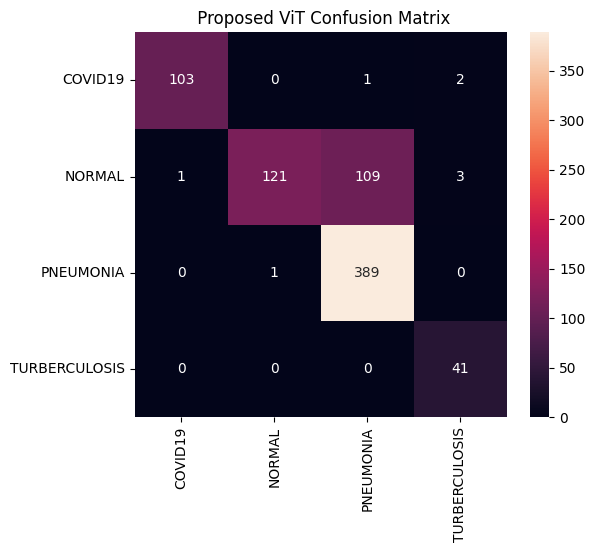

In [42]:
import seaborn as sns 

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(" Proposed ViT Confusion Matrix")

plt.show()

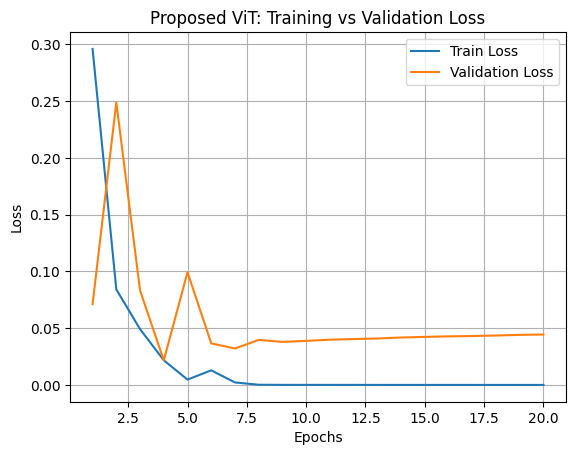

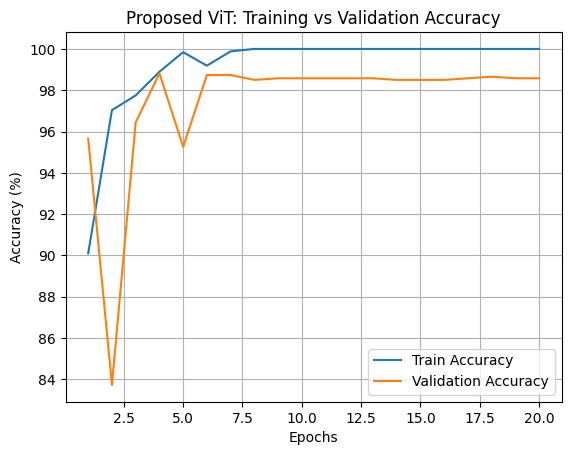

In [43]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

# -------- LOSS --------
plt.figure()
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Proposed ViT: Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# -------- ACCURACY --------
plt.figure()
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Proposed ViT: Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

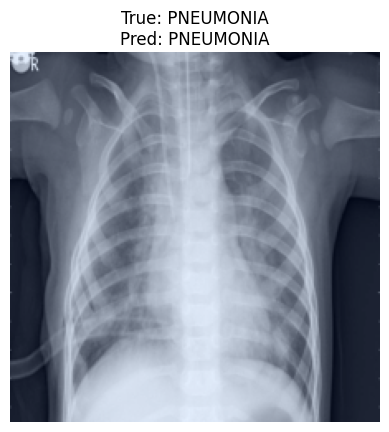

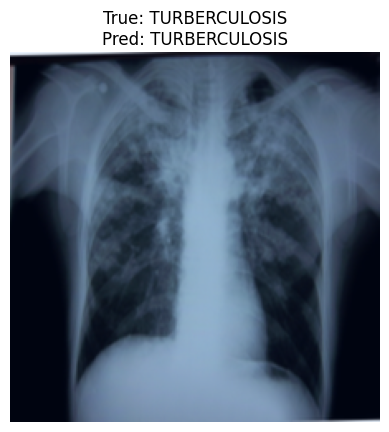

In [94]:
import matplotlib.pyplot as plt
import random

chosen_dataset = test_dataset   

indices = random.sample(range(len(chosen_dataset)), 2)

for idx in indices:
    img, label = chosen_dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)

    img_np = img.permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    plt.imshow(img_np)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred.item()]}")
    plt.axis("off")
    plt.show()


In [44]:
!pip install gradio


In [45]:
import gradio as gr
import torch
import timm
import torchvision.transforms as transforms
from PIL import Image

metadata = torch.load("/kaggle/working/dataset_metadata.pth", map_location="cpu")
class_names = metadata["classes"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=len(class_names))
model.load_state_dict(torch.load("/kaggle/working/plain_vit_best.pth", map_location=device))
model.eval().to(device)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

def predict(image):
    image = image.convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
    return {class_names[i]: float(probs[i]) for i in range(len(class_names))}

iface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=4),
    title="X-ray Disease Classification (ViT)",
    description="Upload an X-ray image to see predicted disease"
)

iface.launch()


* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://97c9d526203ccfeeaa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv


In [ ]:
!zip -r vit_models.zip /kaggle/working/plain_vit_best.pth /kaggle/working/proposed_vit_best.pth /kaggle/working/dataset_metadata.pth


In [ ]:
!zip -r model_files.zip /kaggle/working/plain_vit_best.pth /kaggle/working/dataset_metadata.pth
